# Sideview glancing-incidence Au 10 keV angle sweep to 10 degrees

Focused variant of `sideview_glancing_incidence_au10kev_angle_sweep.ipynb`. The material/energy remain fixed to Au at 10 keV, the detailed sideview plot uses 10 degrees, and the below-surface slab depth is doubled to keep the tilted beam from wrapping through the transverse FFT boundary.


In [1]:
import importlib
import json
from pathlib import Path
import time

import abtem
from ase.build import bulk
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import wide_angle_propagation.propagation_methods as pm

pm = importlib.reload(pm)
from wide_angle_propagation.propagation_methods import (
    energy2wavelength,
    simulate_bidirectional_wpm_1d,
    simulate_glancing_fresnel_baseline_1d,
)
from wide_angle_propagation.sideview_geometry import make_tilted_gaussian_beam_1d

abtem.config.set({"device": "cpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)


In [2]:
energy = 10e3
material_label = "Au"
material_spec = {"symbol": "Au", "crystalstructure": "fcc", "a": 4.078}

# Physical slab dimensions keep the 100 nm path length but double the
# below-surface slab depth from 50 A to 100 A for the 10 degree case.
slab_width_nm = 100.0
slab_width_A = 10.0 * slab_width_nm
slab_depth_A = 100.0
slab_depth_nm = slab_depth_A / 10.0

# A 10 degree beam aimed at u=0 halfway through the 100 nm path starts near
# +88 A and exits near -88 A. The top window and doubled depth keep that path
# away from the periodic transverse boundary.
u_top_margin_A = 110.0
u_bottom_margin_A = 10.0

# Keep the same methods and 50% Nyquist safety criterion. The larger
# transverse grid is needed because the 10 degree carrier has q=sin(10 deg).
n_u = 1280
path_step_target_A = 0.75
n_steps = int(np.ceil(slab_width_A / path_step_target_A))
pade_order = (4, 4)
backscatter_sweeps = 1
wpm_bins = 32
nyquist_safety_fraction = 0.50

# The detailed plot uses 10 degrees; the sweep asks how the method split changes
# as the input carrier is pushed toward the wide-angle regime.
detailed_glancing_angle_degrees = 10.0
angle_sweep_degrees = [2.0, 4.0, 6.0, 8.0, 10.0]

u_min_A = -slab_depth_A - u_bottom_margin_A
u_max_A = u_top_margin_A
du = (u_max_A - u_min_A) / n_u
path_step = slab_width_A / n_steps
u = u_min_A + (jnp.arange(n_u) + 0.5) * du
slice_axis = (np.arange(n_steps) + 0.5) * path_step

beam_waist = 3.0
target_atom_u = 0.0
target_path_coordinate = 0.5 * slab_width_A
abtem_sampling_A = 0.35
wavelength_A = float(energy2wavelength(energy))

# Build one cubic Au FCC unit-cell sideview potential with abTEM/Lobato.
material_lattice_A = material_spec["a"]
material_unit = bulk(
    material_spec["symbol"],
    material_spec["crystalstructure"],
    a=material_lattice_A,
    cubic=True,
)
material_unit.pbc = [True, True, True]
projection_thickness_A = float(material_unit.cell.lengths()[1])

material_potential = abtem.Potential(
    material_unit,
    sampling=abtem_sampling_A,
    slice_thickness=projection_thickness_A,
    projection="finite",
    parametrization="lobato",
    plane="xz",
    device="cpu",
)
unit_projected = np.asarray(material_potential.build(lazy=False).array)[0] / projection_thickness_A
unit_du, unit_ds = (float(v) for v in material_potential.sampling)
unit_u_period_A = unit_du * unit_projected.shape[0]
unit_s_period_A = unit_ds * unit_projected.shape[1]


def input_beam_center_for_angle(angle_degrees):
    angle_rad = np.deg2rad(float(angle_degrees))
    return float(target_atom_u + target_path_coordinate * np.tan(angle_rad))


def input_beam_tilt_for_angle(angle_degrees):
    return -jnp.deg2rad(float(angle_degrees))


def make_input_wave_for_angle(angle_degrees):
    tilt = input_beam_tilt_for_angle(angle_degrees)
    return make_tilted_gaussian_beam_1d(
        u,
        energy,
        waist=beam_waist,
        center=input_beam_center_for_angle(angle_degrees),
        tilt=tilt,
    ).astype(jnp.complex128)


def angle_sampling_diagnostics(angle_degrees):
    tilt = input_beam_tilt_for_angle(angle_degrees)
    tilt_frequency = float(jnp.sin(jnp.abs(tilt)) / wavelength_A)
    nyquist_frequency = 1.0 / (2.0 * du)
    carrier_q = float(abs(np.sin(np.deg2rad(float(angle_degrees)))))
    return {
        "angle_degrees": float(angle_degrees),
        "input_center_u_A": input_beam_center_for_angle(angle_degrees),
        "carrier_q": carrier_q,
        "tilt_nyquist_fraction": tilt_frequency / nyquist_frequency,
        "carrier_exact_minus_fresnel_phase_rad_over_slab": float(
            2.0
            * np.pi
            * slab_width_A
            / wavelength_A
            * (np.sqrt(max(0.0, 1.0 - carrier_q**2)) - (1.0 - 0.5 * carrier_q**2))
        ),
    }


max_tilt_nyquist_fraction = max(
    angle_sampling_diagnostics(angle)["tilt_nyquist_fraction"]
    for angle in angle_sweep_degrees
)
lattice_frequency = 1.0 / material_lattice_A
path_nyquist_frequency = 1.0 / (2.0 * path_step)
lattice_nyquist_fraction = lattice_frequency / path_nyquist_frequency
if max_tilt_nyquist_fraction >= nyquist_safety_fraction:
    raise ValueError("Transverse grid is too close to Nyquist for the requested angle sweep")
if lattice_nyquist_fraction >= nyquist_safety_fraction:
    raise ValueError("Path grid is too close to Nyquist for the Au lattice repeat")

# Tile the abTEM unit-cell potential onto the slab dimensions at the method grid points.
u_np = np.asarray(u)
s_np = np.asarray(slice_axis)
slab_mask = (u_np >= -slab_depth_A) & (u_np <= 0.0)
slab_depth_coordinate = u_np[slab_mask] + slab_depth_A
u_indices = np.floor(np.mod(slab_depth_coordinate, unit_u_period_A) / unit_du).astype(int)
s_indices = np.floor(np.mod(s_np, unit_s_period_A) / unit_ds).astype(int)
u_indices = np.clip(u_indices, 0, unit_projected.shape[0] - 1)
s_indices = np.clip(s_indices, 0, unit_projected.shape[1] - 1)

potential_slices_np = np.zeros((n_steps, n_u), dtype=np.float64)
potential_slices_np[:, slab_mask] = unit_projected[np.ix_(u_indices, s_indices)].T
potential_slices = jnp.asarray(potential_slices_np)

# Atom markers for plotting only. The simulated potential above comes from the tiled Lobato unit cell.
unit_positions = np.asarray(material_unit.positions, dtype=float)
unit_u_positions = unit_positions[:, 0]
unit_s_positions = unit_positions[:, 2]
n_tile_u = int(np.ceil(slab_depth_A / material_lattice_A)) + 1
n_tile_s = int(np.ceil(slab_width_A / material_lattice_A)) + 1
atom_marker_u = []
atom_marker_s = []
for iu in range(n_tile_u):
    for is_ in range(n_tile_s):
        atom_marker_u.append(-slab_depth_A + unit_u_positions + iu * material_lattice_A)
        atom_marker_s.append(unit_s_positions + is_ * material_lattice_A)
atom_marker_u = np.concatenate(atom_marker_u)
atom_marker_s = np.concatenate(atom_marker_s)
marker_mask = (
    (atom_marker_u >= -slab_depth_A)
    & (atom_marker_u <= 0.0)
    & (atom_marker_s >= 0.0)
    & (atom_marker_s <= slab_width_A)
)
atom_marker_u = atom_marker_u[marker_mask]
atom_marker_s = atom_marker_s[marker_mask]

configuration_summary = {
    "material": material_label,
    "energy_keV": float(energy / 1e3),
    "wavelength_A": wavelength_A,
    "slab_size_nm": (slab_width_nm, slab_depth_nm),
    "grid_shape": tuple(potential_slices.shape),
    "sampling_A": (float(du), float(path_step)),
    "du_over_lambda": float(du / wavelength_A),
    "path_step_over_lambda": float(path_step / wavelength_A),
    "pade_order": pade_order,
    "backscatter_sweeps": backscatter_sweeps,
    "wpm_bins": wpm_bins,
    "nyquist_safety_fraction": nyquist_safety_fraction,
    "max_tilt_nyquist_fraction": float(max_tilt_nyquist_fraction),
    "lattice_nyquist_fraction": float(lattice_nyquist_fraction),
    "angle_sampling": [angle_sampling_diagnostics(angle) for angle in angle_sweep_degrees],
}
configuration_summary


{'material': 'Au',
 'energy_keV': 10.0,
 'wavelength_A': 0.12204694974281675,
 'slab_size_nm': (100.0, 10.0),
 'grid_shape': (1334, 1280),
 'sampling_A': (0.171875, 0.7496251874062968),
 'du_over_lambda': 1.4082695254751005,
 'path_step_over_lambda': 6.142105058634757,
 'pade_order': (4, 4),
 'backscatter_sweeps': 1,
 'wpm_bins': 32,
 'nyquist_safety_fraction': 0.5,
 'max_tilt_nyquist_fraction': 0.4890868735252479,
 'lattice_nyquist_fraction': 0.36764354458376497,
 'angle_sampling': [{'angle_degrees': 2.0,
   'input_center_u_A': 17.460384745873863,
   'carrier_q': 0.03489949670250097,
   'tilt_nyquist_fraction': 0.09829579532110176,
   'carrier_exact_minus_fresnel_phase_rad_over_slab': -0.009552217617651121},
  {'angle_degrees': 4.0,
   'input_center_u_A': 34.96340597175521,
   'carrier_q': 0.0697564737441253,
   'tilt_nyquist_fraction': 0.1964718323569113,
   'carrier_exact_minus_fresnel_phase_rad_over_slab': -0.1527423928009489},
  {'angle_degrees': 6.0,
   'input_center_u_A': 52.552

In [3]:
def precompute_pade_operators_for_keys(potential_slices_case, slice_keys, dx, dz, energy_eV, order):
    operators = {}
    keys = np.asarray(slice_keys)
    k0 = 1.0 / energy2wavelength(energy_eV)
    for key in np.unique(keys):
        first_index = int(np.flatnonzero(keys == key)[0])
        operator_x, n0 = pm.build_sideview_operator_x_1d(
            potential_slices_case[first_index],
            dx,
            energy_eV,
            n0_mode="slice_mean",
            transverse_operator="spectral",
        )
        sqrt_operator = pm._pade_sqrt_matrix(operator_x, order)
        generator = 1j * 2.0 * jnp.pi * dz * k0 * n0 * sqrt_operator
        operators[int(key)] = {
            "forward": jax.scipy.linalg.expm(generator),
            "backward": jax.scipy.linalg.expm(-generator),
        }
    return operators


def apply_scalar_interface_matrix(scattering_matrix, plus_from_left, minus_from_right):
    plus_right = scattering_matrix[0, 0] * plus_from_left + scattering_matrix[0, 1] * minus_from_right
    minus_left = scattering_matrix[1, 0] * plus_from_left + scattering_matrix[1, 1] * minus_from_right
    return plus_right, minus_left


def simulate_cached_pade_exit(
    potential_slices_case,
    slice_keys,
    input_wave_case,
    *,
    operators,
    interface_matrices,
    n_sweeps,
    keep_wavefronts=False,
):
    n_slices = potential_slices_case.shape[0]
    keys = np.asarray(slice_keys)
    zero = jnp.zeros_like(input_wave_case)

    def forward_pass(backward_boundary):
        wave_plus = input_wave_case
        wavefronts_plus = []
        plus_at_interfaces = [zero for _ in range(n_slices + 1)]
        for j in range(n_slices):
            wave_plus = operators[int(keys[j])]["forward"] @ wave_plus
            if keep_wavefronts:
                wavefronts_plus.append(wave_plus)
            plus_at_interfaces[j + 1] = wave_plus
            if j + 1 < n_slices:
                wave_plus, _ = apply_scalar_interface_matrix(
                    interface_matrices[j],
                    wave_plus,
                    backward_boundary[j + 1],
                )
        return wave_plus, wavefronts_plus, plus_at_interfaces

    def backward_pass(plus_at_interfaces):
        new_backward = [zero for _ in range(n_slices + 1)]
        wave_minus = zero
        for j in range(n_slices - 2, -1, -1):
            new_backward[j + 1] = wave_minus
            _, minus_left = apply_scalar_interface_matrix(
                interface_matrices[j],
                plus_at_interfaces[j + 1],
                wave_minus,
            )
            wave_minus = operators[int(keys[j])]["backward"] @ minus_left
            new_backward[j] = wave_minus
        return new_backward

    backward_boundary = [zero for _ in range(n_slices + 1)]
    residuals = []
    for _ in range(max(int(n_sweeps), 1)):
        _, _, plus_at_interfaces = forward_pass(backward_boundary)
        new_backward = backward_pass(plus_at_interfaces)
        residuals.append(float(pm._residual_between_boundary_lists(new_backward, backward_boundary, input_wave_case)))
        backward_boundary = new_backward

    transmitted, wavefronts_plus, plus_at_interfaces = forward_pass(backward_boundary)
    final_backward = backward_pass(plus_at_interfaces)
    diagnostics = {
        "residual_per_sweep": residuals,
        "cached_unique_slices": int(np.unique(keys).size),
    }
    if keep_wavefronts:
        diagnostics["wavefronts_plus"] = jnp.stack(wavefronts_plus)
    return transmitted, final_backward[0], diagnostics


def align_to_reference(candidate, reference):
    scale = jnp.vdot(candidate, reference) / (jnp.vdot(candidate, candidate) + 1e-30)
    return scale * candidate


def relative_complex_rmse(candidate, reference, mask=None):
    candidate = align_to_reference(candidate, reference)
    if mask is not None:
        candidate = candidate[mask]
        reference = reference[mask]
    return jnp.linalg.norm(candidate - reference) / (jnp.linalg.norm(reference) + 1e-30)


def normalized_profile_rmse(candidate_values, reference_values, mask=None):
    candidate_values = jnp.asarray(candidate_values)
    reference_values = jnp.asarray(reference_values)
    if mask is not None:
        candidate_values = candidate_values[mask]
        reference_values = reference_values[mask]
    scale = jnp.vdot(candidate_values, reference_values) / (
        jnp.vdot(candidate_values, candidate_values) + 1e-30
    )
    return jnp.sqrt(jnp.mean((scale * candidate_values - reference_values) ** 2)) / (
        jnp.sqrt(jnp.mean(reference_values**2)) + 1e-30
    )


def weighted_quantile(values, weights, quantiles):
    values = np.asarray(values, dtype=float).ravel()
    weights = np.asarray(weights, dtype=float).ravel()
    quantiles = np.asarray(quantiles, dtype=float)
    finite = np.isfinite(values) & np.isfinite(weights) & (weights > 0.0)
    if not np.any(finite):
        return np.full_like(quantiles, np.nan, dtype=float)
    values = values[finite]
    weights = weights[finite]
    order = np.argsort(values)
    values = values[order]
    cumulative = np.cumsum(weights[order])
    cumulative /= cumulative[-1]
    return np.interp(quantiles, cumulative, values)


def exact_minus_fresnel_phase_error_rad(q, distance_A, wavelength_A):
    q = np.asarray(q, dtype=float)
    q = np.clip(np.abs(q), 0.0, 1.0)
    exact_longitudinal = np.sqrt(np.maximum(0.0, 1.0 - q**2))
    fresnel_longitudinal = 1.0 - 0.5 * q**2
    return 2.0 * np.pi * distance_A / wavelength_A * (exact_longitudinal - fresnel_longitudinal)


spatial_frequency = np.fft.fftshift(np.fft.fftfreq(n_u, d=du))
detector_angle_rad = np.arcsin(np.clip(spatial_frequency * wavelength_A, -1.0, 1.0))
detector_angle_mrad = 1e3 * detector_angle_rad
positive_angle_mask = detector_angle_mrad > 0.0
q_shifted = wavelength_A * spatial_frequency
refractive_maps = pm.klein_gordon_refractive_index_1d(potential_slices, energy)
interface_matrices = [
    pm.interface_scattering_matrix_1d(refractive_maps[j], refractive_maps[j + 1])
    for j in range(potential_slices.shape[0] - 1)
]
pade_operators = precompute_pade_operators_for_keys(
    potential_slices,
    s_indices,
    du,
    path_step,
    energy,
    pade_order,
)


def run_methods_for_angle(angle_degrees, *, keep_wavefronts=False):
    input_wave_case = make_input_wave_for_angle(angle_degrees)
    results = {}

    fresnel_wave, _, fresnel_diag = simulate_glancing_fresnel_baseline_1d(
        input_wave_case,
        potential_slices,
        du,
        path_step,
        energy,
        input_tilt=0.0,
    )
    results["Fresnel"] = {
        "wave": fresnel_wave,
        "reflected": jnp.zeros_like(fresnel_wave),
        "wavefronts": fresnel_diag["wavefronts"] if keep_wavefronts else None,
        "diagnostics": fresnel_diag,
    }

    wpm_wave, wpm_reflected, _, wpm_diag = simulate_bidirectional_wpm_1d(
        potential_slices,
        input_wave_case,
        du,
        path_step,
        energy,
        n_bins=wpm_bins,
        n_sweeps=backscatter_sweeps,
    )
    results["WPM"] = {
        "wave": wpm_wave,
        "reflected": wpm_reflected,
        "wavefronts": wpm_diag["wavefronts_plus"] if keep_wavefronts else None,
        "diagnostics": wpm_diag,
    }

    pade_wave, pade_reflected, pade_diag = simulate_cached_pade_exit(
        potential_slices,
        s_indices,
        input_wave_case,
        operators=pade_operators,
        interface_matrices=interface_matrices,
        n_sweeps=backscatter_sweeps,
        keep_wavefronts=keep_wavefronts,
    )
    results["Pade"] = {
        "wave": pade_wave,
        "reflected": pade_reflected,
        "wavefronts": pade_diag.get("wavefronts_plus"),
        "diagnostics": pade_diag,
    }
    return input_wave_case, results


def summarize_method_results(method_results_case):
    fresnel_wave = method_results_case["Fresnel"]["wave"]
    farfields = {
        name: jnp.abs(jnp.fft.fftshift(jnp.fft.fft(result["wave"]))) ** 2
        for name, result in method_results_case.items()
    }
    exit_mask = jnp.abs(fresnel_wave) ** 2 > 1e-3 * jnp.max(jnp.abs(fresnel_wave) ** 2)
    summary = {}
    for name, result in method_results_case.items():
        q50, q90, q99 = weighted_quantile(
            np.abs(q_shifted),
            np.asarray(farfields[name]),
            [0.50, 0.90, 0.99],
        )
        summary[name] = {
            "exit_field_rmse_vs_fresnel": float(relative_complex_rmse(result["wave"], fresnel_wave, exit_mask)),
            "exit_intensity_rmse_vs_fresnel": float(
                normalized_profile_rmse(jnp.abs(result["wave"]) ** 2, jnp.abs(fresnel_wave) ** 2, exit_mask)
            ),
            "positive_farfield_rmse_vs_fresnel": float(
                normalized_profile_rmse(farfields[name][positive_angle_mask], farfields["Fresnel"][positive_angle_mask])
            ),
            "reflected_power": float(jnp.sum(jnp.abs(result["reflected"]) ** 2)),
            "transmitted_power": float(jnp.sum(jnp.abs(result["wave"]) ** 2)),
            "q50": float(q50),
            "q90": float(q90),
            "q99": float(q99),
            "theta99_mrad": float(1e3 * np.arcsin(np.clip(q99, 0.0, 1.0))),
        }
    return summary, farfields

methods = ["Fresnel", "WPM", "Pade"]
method_colors = {"Fresnel": "0.15", "WPM": "tab:blue", "Pade": "tab:orange"}


In [4]:
input_wave, method_results = run_methods_for_angle(
    detailed_glancing_angle_degrees,
    keep_wavefronts=True,
)
comparison_summary, method_farfields = summarize_method_results(method_results)

assert all(jnp.all(jnp.isfinite(result["wave"])) for result in method_results.values())
assert all(np.isfinite(value) for row in comparison_summary.values() for value in row.values())

incident_angle_mrad = -1e3 * np.deg2rad(detailed_glancing_angle_degrees)
bounced_angle_mrad = -incident_angle_mrad

detailed_case_summary = {
    "configuration": configuration_summary,
    "detailed_angle_degrees": detailed_glancing_angle_degrees,
    "detailed_angle_sampling": angle_sampling_diagnostics(detailed_glancing_angle_degrees),
    "cached_unique_slices": method_results["Pade"]["diagnostics"]["cached_unique_slices"],
    "method_summary": comparison_summary,
}
detailed_case_summary


{'configuration': {'material': 'Au',
  'energy_keV': 10.0,
  'wavelength_A': 0.12204694974281675,
  'slab_size_nm': (100.0, 10.0),
  'grid_shape': (1334, 1280),
  'sampling_A': (0.171875, 0.7496251874062968),
  'du_over_lambda': 1.4082695254751005,
  'path_step_over_lambda': 6.142105058634757,
  'pade_order': (4, 4),
  'backscatter_sweeps': 1,
  'wpm_bins': 32,
  'nyquist_safety_fraction': 0.5,
  'max_tilt_nyquist_fraction': 0.4890868735252479,
  'lattice_nyquist_fraction': 0.36764354458376497,
  'angle_sampling': [{'angle_degrees': 2.0,
    'input_center_u_A': 17.460384745873863,
    'carrier_q': 0.03489949670250097,
    'tilt_nyquist_fraction': 0.09829579532110176,
    'carrier_exact_minus_fresnel_phase_rad_over_slab': -0.009552217617651121},
   {'angle_degrees': 4.0,
    'input_center_u_A': 34.96340597175521,
    'carrier_q': 0.0697564737441253,
    'tilt_nyquist_fraction': 0.1964718323569113,
    'carrier_exact_minus_fresnel_phase_rad_over_slab': -0.1527423928009489},
   {'angle_de

In [7]:
run_angle_sweep = False
use_saved_angle_results = True
angle_cache_dir = Path("notebook_results") / "sideview_glancing_incidence_au10kev_10deg_angle_sweep"
angle_cache_tag = (
    f"{material_label}_{energy / 1e3:.0f}keV_width{slab_width_A:.0f}A_depth{slab_depth_A:.0f}A_"
    f"grid{n_steps}x{n_u}_pade{pade_order[0]}{pade_order[1]}_sweeps{backscatter_sweeps}_v1"
).replace(".", "p")
angle_case_cache_dir = angle_cache_dir / angle_cache_tag
angle_case_cache_dir.mkdir(parents=True, exist_ok=True)
angle_summary_path = angle_case_cache_dir / "angle_sweep_summary.json"


def angle_cache_path(angle_degrees):
    angle_label = f"{float(angle_degrees):04.1f}deg".replace(".", "p")
    return angle_case_cache_dir / f"angle_{angle_label}_cross_sections.npz"


def load_cached_angle_row(cache_path):
    with np.load(cache_path, allow_pickle=False) as data:
        row = json.loads(data["metadata_json"].item())
    row["cache_file"] = str(cache_path)
    row["loaded_from_cache"] = True
    return row


def load_angle_case_cross_sections(cache_file):
    with np.load(cache_file, allow_pickle=False) as data:
        result = {name: data[name].copy() for name in data.files if name != "metadata_json"}
        result["metadata"] = json.loads(data["metadata_json"].item())
    return result


def save_angle_case_cross_sections(cache_path, angle_degrees, input_wave_case, method_results_case, farfields, row):
    metadata = dict(row)
    metadata["loaded_from_cache"] = False
    np.savez_compressed(
        cache_path,
        metadata_json=np.array(json.dumps(metadata)),
        u_A=np.asarray(u),
        detector_angle_mrad=np.asarray(detector_angle_mrad),
        input_wave=np.asarray(input_wave_case),
        fresnel_exit=np.asarray(method_results_case["Fresnel"]["wave"]),
        wpm_exit=np.asarray(method_results_case["WPM"]["wave"]),
        pade_exit=np.asarray(method_results_case["Pade"]["wave"]),
        wpm_reflected=np.asarray(method_results_case["WPM"]["reflected"]),
        pade_reflected=np.asarray(method_results_case["Pade"]["reflected"]),
        fresnel_farfield=np.asarray(farfields["Fresnel"]),
        wpm_farfield=np.asarray(farfields["WPM"]),
        pade_farfield=np.asarray(farfields["Pade"]),
    )


def build_angle_row(angle_degrees, method_results_case, farfields, elapsed_s):
    method_summary = summarize_method_results(method_results_case)[0]
    wpm_diag = method_results_case["WPM"]["diagnostics"]
    pade_diag = method_results_case["Pade"]["diagnostics"]
    row = {
        "material": material_label,
        "energy_keV": float(energy / 1e3),
        "angle_degrees": float(angle_degrees),
        "grid_shape": tuple(potential_slices.shape),
        "sampling_A": (float(du), float(path_step)),
        "du_over_lambda": float(du / wavelength_A),
        "path_step_over_lambda": float(path_step / wavelength_A),
        "input_center_u_A": input_beam_center_for_angle(angle_degrees),
        "tilt_nyquist_fraction": angle_sampling_diagnostics(angle_degrees)["tilt_nyquist_fraction"],
        "lattice_nyquist_fraction": float(lattice_nyquist_fraction),
        "carrier_phase_error_rad_over_slab": float(
            abs(angle_sampling_diagnostics(angle_degrees)["carrier_exact_minus_fresnel_phase_rad_over_slab"])
        ),
        "cached_unique_slices": pade_diag["cached_unique_slices"],
        "runtime_s": float(elapsed_s),
        "wpm_exit_intensity_rmse_vs_fresnel": method_summary["WPM"]["exit_intensity_rmse_vs_fresnel"],
        "pade_exit_intensity_rmse_vs_fresnel": method_summary["Pade"]["exit_intensity_rmse_vs_fresnel"],
        "pade_exit_intensity_rmse_vs_wpm": float(
            normalized_profile_rmse(
                jnp.abs(method_results_case["Pade"]["wave"]) ** 2,
                jnp.abs(method_results_case["WPM"]["wave"]) ** 2,
                jnp.abs(method_results_case["Fresnel"]["wave"]) ** 2
                > 1e-3 * jnp.max(jnp.abs(method_results_case["Fresnel"]["wave"]) ** 2),
            )
        ),
        "wpm_farfield_rmse_vs_fresnel": method_summary["WPM"]["positive_farfield_rmse_vs_fresnel"],
        "pade_farfield_rmse_vs_fresnel": method_summary["Pade"]["positive_farfield_rmse_vs_fresnel"],
        "pade_farfield_rmse_vs_wpm": float(
            normalized_profile_rmse(farfields["Pade"][positive_angle_mask], farfields["WPM"][positive_angle_mask])
        ),
        "wpm_reflected_power": method_summary["WPM"]["reflected_power"],
        "pade_reflected_power": method_summary["Pade"]["reflected_power"],
        "fresnel_q99": method_summary["Fresnel"]["q99"],
        "wpm_q99": method_summary["WPM"]["q99"],
        "pade_q99": method_summary["Pade"]["q99"],
        "wpm_residual_last": float(wpm_diag["residual_per_sweep"][-1]) if len(wpm_diag["residual_per_sweep"]) else 0.0,
        "pade_residual_last": float(pade_diag["residual_per_sweep"][-1]) if len(pade_diag["residual_per_sweep"]) else 0.0,
        "cache_file": str(angle_cache_path(angle_degrees)),
        "loaded_from_cache": False,
    }
    assert all(np.isfinite(value) for value in row.values() if isinstance(value, float))
    return row


def run_angle_case(angle_degrees):
    cache_path = angle_cache_path(angle_degrees)
    if use_saved_angle_results and cache_path.exists():
        return load_cached_angle_row(cache_path)

    start = time.perf_counter()
    if np.isclose(float(angle_degrees), float(detailed_glancing_angle_degrees)):
        input_wave_case = input_wave
        method_results_case = method_results
        farfields = method_farfields
    else:
        input_wave_case, method_results_case = run_methods_for_angle(angle_degrees, keep_wavefronts=False)
        _, farfields = summarize_method_results(method_results_case)
    elapsed_s = time.perf_counter() - start
    row = build_angle_row(angle_degrees, method_results_case, farfields, elapsed_s)
    save_angle_case_cross_sections(cache_path, angle_degrees, input_wave_case, method_results_case, farfields, row)
    return row


angle_sweep_results = []
if run_angle_sweep:
    for angle_degrees in angle_sweep_degrees:
        angle_sweep_results.append(run_angle_case(angle_degrees))

angle_sweep_summary = {
    "cache_dir": str(angle_case_cache_dir),
    "summary_file": str(angle_summary_path),
    "material": material_label,
    "energy_keV": float(energy / 1e3),
    "angle_sweep_degrees": angle_sweep_degrees,
    "grid_shape": (n_steps, n_u),
    "sampling_A": (float(du), float(path_step)),
    "pade_order": pade_order,
    "wpm_bins": wpm_bins,
    "backscatter_sweeps": backscatter_sweeps,
    "nyquist_safety_fraction": nyquist_safety_fraction,
    "max_tilt_nyquist_fraction": float(max_tilt_nyquist_fraction),
    "lattice_nyquist_fraction": float(lattice_nyquist_fraction),
    "angle_results": angle_sweep_results,
}
if run_angle_sweep:
    angle_summary_path.write_text(json.dumps(angle_sweep_summary, indent=2))
angle_sweep_summary


{'cache_dir': 'notebook_results/sideview_glancing_incidence_au10kev_10deg_angle_sweep/Au_10keV_width1000A_depth100A_grid1334x1280_pade44_sweeps1_v1',
 'summary_file': 'notebook_results/sideview_glancing_incidence_au10kev_10deg_angle_sweep/Au_10keV_width1000A_depth100A_grid1334x1280_pade44_sweeps1_v1/angle_sweep_summary.json',
 'material': 'Au',
 'energy_keV': 10.0,
 'angle_sweep_degrees': [2.0, 4.0, 6.0, 8.0, 10.0],
 'grid_shape': (1334, 1280),
 'sampling_A': (0.171875, 0.7496251874062968),
 'pade_order': (4, 4),
 'wpm_bins': 32,
 'backscatter_sweeps': 1,
 'nyquist_safety_fraction': 0.5,
 'max_tilt_nyquist_fraction': 0.4890868735252479,
 'lattice_nyquist_fraction': 0.36764354458376497,
 'angle_results': []}

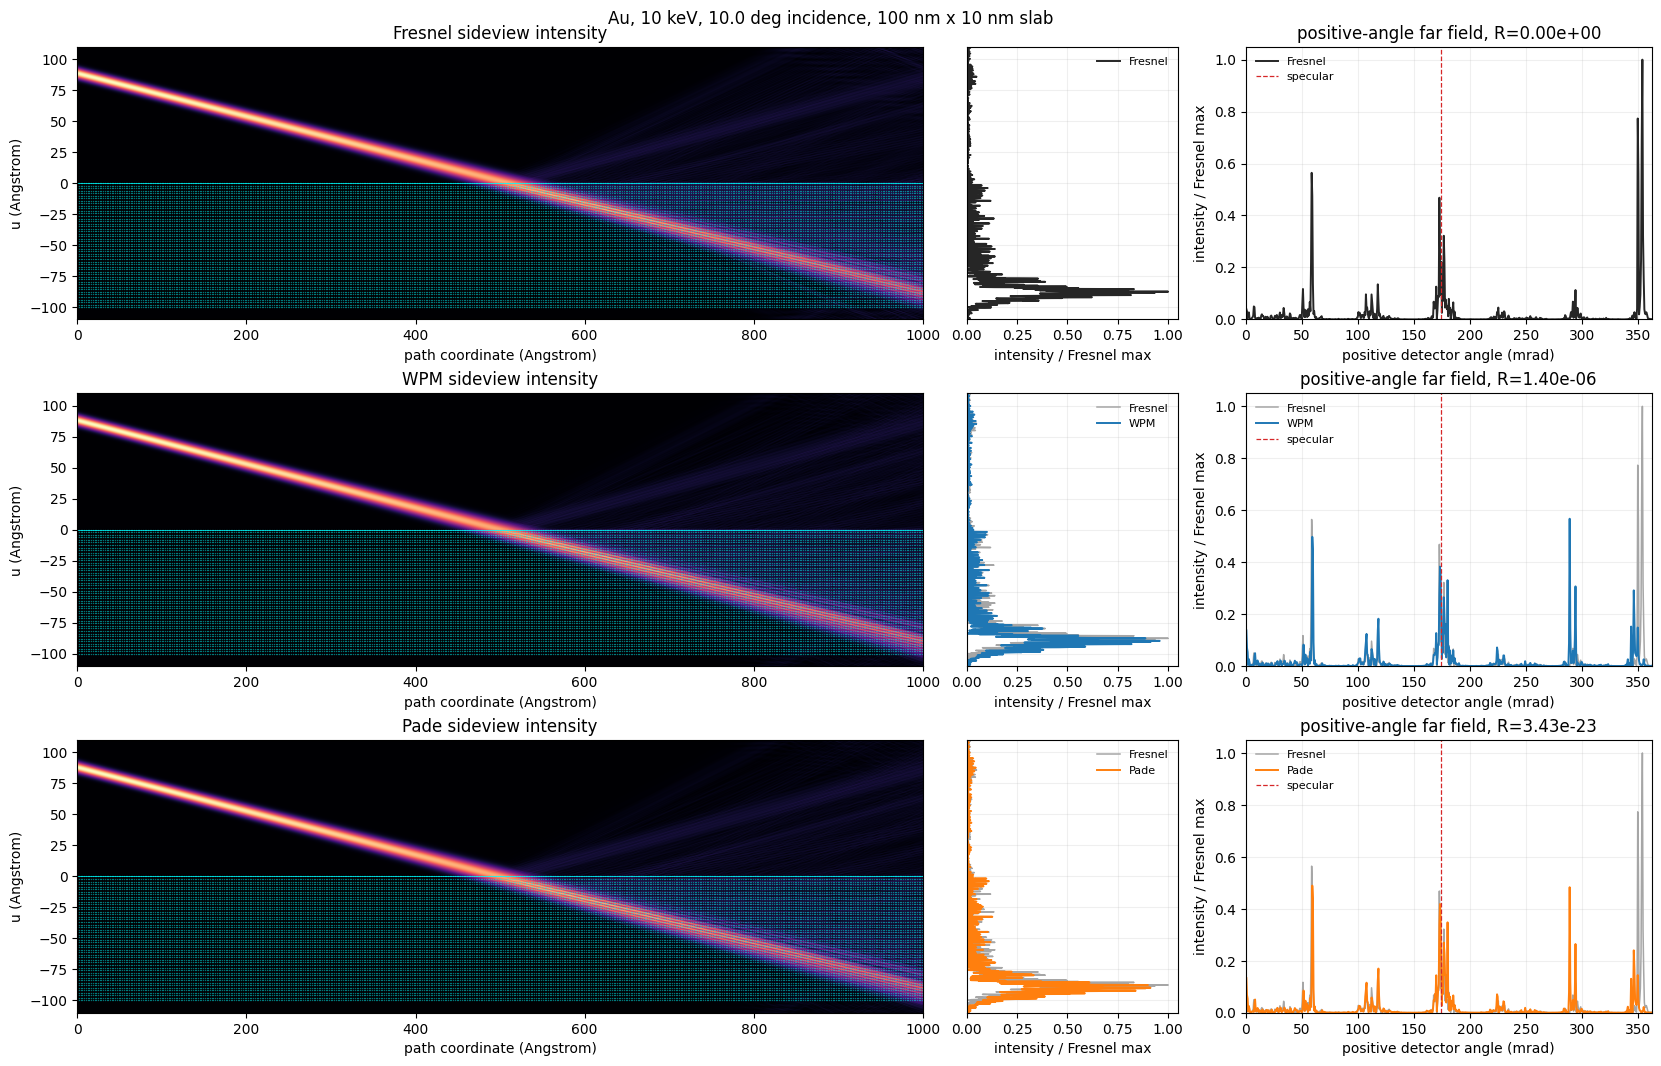

{'Fresnel': {'exit_field_rmse_vs_fresnel': 0.0,
  'exit_intensity_rmse_vs_fresnel': 0.0,
  'positive_farfield_rmse_vs_fresnel': 0.0,
  'reflected_power': 0.0,
  'transmitted_power': 30.937376306718367,
  'q50': 0.17868389017488306,
  'q90': 0.18917277210136596,
  'q99': 0.3472790479045604,
  'theta99_mrad': 354.66800048385994},
 'WPM': {'exit_field_rmse_vs_fresnel': 0.7352762903800801,
  'exit_intensity_rmse_vs_fresnel': 0.41776691094406343,
  'positive_farfield_rmse_vs_fresnel': 0.8966271862937598,
  'reflected_power': 1.404348749499181e-06,
  'transmitted_power': 31.089891522838784,
  'q50': 0.1787256275735988,
  'q90': 0.18510236005734712,
  'q99': 0.3395124238300175,
  'theta99_mrad': 346.398482685141},
 'Pade': {'exit_field_rmse_vs_fresnel': 0.7535504480960449,
  'exit_intensity_rmse_vs_fresnel': 0.401204399135719,
  'positive_farfield_rmse_vs_fresnel': 0.8843425272874956,
  'reflected_power': 3.427965442683171e-23,
  'transmitted_power': 30.937375970713994,
  'q50': 0.17871142800

In [8]:
sideview_norm = max(
    float(jnp.max(jnp.abs(method_results[method]["wavefronts"]) ** 2))
    for method in methods
) + 1e-30
exit_norm = float(jnp.max(jnp.abs(method_results["Fresnel"]["wave"]) ** 2)) + 1e-30
farfield_norm = float(jnp.max(method_farfields["Fresnel"][positive_angle_mask])) + 1e-30
extent = [0.0, slab_width_A, float(u[0]), float(u[-1])]
u_limits = (float(u[0]), float(u[-1]))
positive_angle_limit = float(np.max(detector_angle_mrad[positive_angle_mask]))
positive_farfield_ylim = 1.05 * max(
    float(jnp.max(method_farfields[method][positive_angle_mask] / farfield_norm))
    for method in methods
)

fig, axes = plt.subplots(
    len(methods),
    3,
    figsize=(16.5, 10.4),
    constrained_layout=True,
    gridspec_kw={"width_ratios": [5.0, 1.25, 2.4]},
)

for row, method in enumerate(methods):
    result = method_results[method]
    wavefront_display = np.sqrt(np.asarray(jnp.abs(result["wavefronts"]) ** 2) / sideview_norm)
    ax_side, ax_out, ax_far = axes[row]

    ax_side.imshow(
        wavefront_display.T,
        extent=extent,
        origin="lower",
        aspect="auto",
        cmap="magma",
        vmin=0.0,
        vmax=1.0,
    )
    ax_side.scatter(
        atom_marker_s,
        atom_marker_u,
        s=1.0,
        c="cyan",
        alpha=0.45,
        linewidths=0,
        rasterized=True,
    )
    ax_side.axhline(0.0, color="cyan", lw=0.7, alpha=0.75)
    ax_side.set_ylim(u_limits)
    ax_side.set_title(f"{method} sideview intensity")
    ax_side.set_xlabel("path coordinate (Angstrom)")
    ax_side.set_ylabel("u (Angstrom)")
    ax_out.sharey(ax_side)

    method_exit = jnp.abs(result["wave"]) ** 2 / exit_norm
    fresnel_exit = jnp.abs(method_results["Fresnel"]["wave"]) ** 2 / exit_norm
    if method != "Fresnel":
        ax_out.plot(np.asarray(fresnel_exit), np.asarray(u), color="0.65", lw=1.1, label="Fresnel")
    ax_out.plot(np.asarray(method_exit), np.asarray(u), color=method_colors[method], lw=1.4, label=method)
    ax_out.set_xlabel("intensity / Fresnel max")
    ax_out.set_xlim(0.0, max(1.05, 1.05 * float(jnp.max(method_exit))))
    ax_out.set_ylim(u_limits)
    ax_out.tick_params(axis="y", left=False, labelleft=False)
    ax_out.grid(alpha=0.2)
    ax_out.legend(fontsize=8, frameon=False)

    method_farfield = method_farfields[method] / farfield_norm
    fresnel_farfield = method_farfields["Fresnel"] / farfield_norm
    if method != "Fresnel":
        ax_far.plot(
            detector_angle_mrad[positive_angle_mask],
            np.asarray(fresnel_farfield)[positive_angle_mask],
            color="0.65",
            lw=1.1,
            label="Fresnel",
        )
    ax_far.plot(
        detector_angle_mrad[positive_angle_mask],
        np.asarray(method_farfield)[positive_angle_mask],
        color=method_colors[method],
        lw=1.4,
        label=method,
    )
    ax_far.axvline(bounced_angle_mrad, color="tab:red", lw=0.9, ls="--", label="specular")
    ax_far.set_xlabel("positive detector angle (mrad)")
    ax_far.set_ylabel("intensity / Fresnel max")
    ax_far.set_xlim(0.0, positive_angle_limit)
    ax_far.set_ylim(0.0, positive_farfield_ylim)
    ax_far.set_title(f"positive-angle far field, R={comparison_summary[method]['reflected_power']:.2e}")
    ax_far.grid(alpha=0.2)
    ax_far.legend(fontsize=8, frameon=False)

fig.suptitle(
    f"{material_label}, {energy / 1e3:.0f} keV, {detailed_glancing_angle_degrees:.1f} deg incidence, "
    f"{slab_width_nm:.0f} nm x {slab_depth_nm:.0f} nm slab",
    y=1.01,
)
plt.show()

comparison_summary


In [9]:
if run_angle_sweep and angle_sweep_results:
    angles = np.array([row["angle_degrees"] for row in angle_sweep_results])

    fig_sweep, axes_sweep = plt.subplots(2, 3, figsize=(14.4, 7.6), constrained_layout=True)
    metric_specs = [
        ("WPM vs Fresnel\nexit intensity RMSE", "wpm_exit_intensity_rmse_vs_fresnel", "tab:blue"),
        ("Pade vs Fresnel\nexit intensity RMSE", "pade_exit_intensity_rmse_vs_fresnel", "tab:orange"),
        ("Pade vs WPM\nexit intensity RMSE", "pade_exit_intensity_rmse_vs_wpm", "tab:green"),
        ("WPM vs Fresnel\npositive far-field RMSE", "wpm_farfield_rmse_vs_fresnel", "tab:blue"),
        ("Pade vs Fresnel\npositive far-field RMSE", "pade_farfield_rmse_vs_fresnel", "tab:orange"),
        ("carrier AS-Fresnel\nphase error over slab", "carrier_phase_error_rad_over_slab", "tab:red"),
    ]
    for ax, (title, metric_name, color) in zip(axes_sweep.ravel(), metric_specs):
        values = np.array([row[metric_name] for row in angle_sweep_results])
        ax.plot(angles, values, "o-", color=color)
        ax.set_xlabel("input angle (deg)")
        ax.set_title(title)
        ax.grid(alpha=0.25)
        if np.all(values > 0):
            ax.set_yscale("log")
    fig_sweep.suptitle(
        f"{material_label} {energy / 1e3:.0f} keV angle sweep, grid={n_steps} x {n_u}, "
        f"du/lambda={du / wavelength_A:.2f}, max tilt Nyquist fraction={max_tilt_nyquist_fraction:.2f}",
        y=1.03,
    )
    plt.show()

    fig_cross, axes_cross = plt.subplots(
        1,
        len(angle_sweep_degrees),
        figsize=(3.25 * len(angle_sweep_degrees), 4.8),
        sharey=True,
        constrained_layout=True,
    )
    method_exit_keys = {"Fresnel": "fresnel_exit", "WPM": "wpm_exit", "Pade": "pade_exit"}
    if len(angle_sweep_degrees) == 1:
        axes_cross = [axes_cross]
    for ax, angle_degrees in zip(axes_cross, angle_sweep_degrees):
        row = next(row for row in angle_sweep_results if np.isclose(row["angle_degrees"], angle_degrees))
        cross_section = load_angle_case_cross_sections(row["cache_file"])
        u_cross = cross_section["u_A"]
        panel_norm = max(
            float(np.max(np.abs(cross_section[key]) ** 2))
            for key in method_exit_keys.values()
        ) + 1e-30
        for method in methods:
            intensity = np.abs(cross_section[method_exit_keys[method]]) ** 2 / panel_norm
            ax.plot(intensity, u_cross, color=method_colors[method], lw=1.3, label=method)
        ax.axhline(0.0, color="0.3", lw=0.7, alpha=0.6)
        ax.set_title(f"{angle_degrees:.0f} deg")
        ax.set_xlabel("exit intensity / panel max")
        ax.set_xlim(left=0.0)
        ax.set_ylim(u_limits)
        ax.grid(alpha=0.2)
    axes_cross[0].set_ylabel("u (Angstrom)")
    axes_cross[0].legend(fontsize=8, frameon=False)
    fig_cross.suptitle(
        f"Exit cross sections loaded from {angle_case_cache_dir}",
        y=1.04,
    )
    cross_section_figure_path = angle_case_cache_dir / "angle_sweep_exit_cross_sections.png"
    fig_cross.savefig(cross_section_figure_path, dpi=180)
    plt.show()

angle_sweep_results


[]

In [10]:
# Compact sampling readout for the selected grid.
sampling_rows = []
for angle_degrees in angle_sweep_degrees:
    diag = angle_sampling_diagnostics(angle_degrees)
    sampling_rows.append(
        {
            **diag,
            "input_center_inside_window": bool(u_min_A <= diag["input_center_u_A"] <= u_max_A),
            "theta_nyquist_deg": float(np.rad2deg(np.arcsin(np.clip(np.max(np.abs(q_shifted)), 0.0, 1.0)))),
        }
    )

sampling_check = {
    "wavelength_A": float(wavelength_A),
    "u_window_A": (float(u_min_A), float(u_max_A)),
    "du_A": float(du),
    "du_over_lambda": float(du / wavelength_A),
    "path_step_A": float(path_step),
    "path_step_over_lambda": float(path_step / wavelength_A),
    "q_nyquist": float(np.max(np.abs(q_shifted))),
    "theta_nyquist_deg": float(np.rad2deg(np.arcsin(np.clip(np.max(np.abs(q_shifted)), 0.0, 1.0)))),
    "angle_rows": sampling_rows,
}
sampling_check


{'wavelength_A': 0.12204694974281675,
 'u_window_A': (-110.0, 110.0),
 'du_A': 0.171875,
 'du_over_lambda': 1.4082695254751005,
 'path_step_A': 0.7496251874062968,
 'path_step_over_lambda': 6.142105058634757,
 'q_nyquist': 0.3550456719791033,
 'theta_nyquist_deg': 20.79624353580479,
 'angle_rows': [{'angle_degrees': 2.0,
   'input_center_u_A': 17.460384745873863,
   'carrier_q': 0.03489949670250097,
   'tilt_nyquist_fraction': 0.09829579532110176,
   'carrier_exact_minus_fresnel_phase_rad_over_slab': -0.009552217617651121,
   'input_center_inside_window': True,
   'theta_nyquist_deg': 20.79624353580479},
  {'angle_degrees': 4.0,
   'input_center_u_A': 34.96340597175521,
   'carrier_q': 0.0697564737441253,
   'tilt_nyquist_fraction': 0.1964718323569113,
   'carrier_exact_minus_fresnel_phase_rad_over_slab': -0.1527423928009489,
   'input_center_inside_window': True,
   'theta_nyquist_deg': 20.79624353580479},
  {'angle_degrees': 6.0,
   'input_center_u_A': 52.55211763283823,
   'carrier_